In [1]:
import cv2
import numpy as np

In [2]:
image = cv2.imread('cropped-detections/crop_1.jpg', cv2.IMREAD_COLOR)

In [4]:
height, width = image.shape[:2]
# get the center coordinates of the image to create the 2D rotation matrix
center = (width/2, height/2)
 
# using cv2.getRotationMatrix2D() to get the rotation matrix
rotate_matrix = cv2.getRotationMatrix2D(center=center, angle=-22, scale=1)
 
# rotate the image using cv2.warpAffine
rotated_image = cv2.warpAffine(src=image, M=rotate_matrix, dsize=(width, height))
 
cv2.imshow('Original image', image)
cv2.imshow('Rotated image', rotated_image)
# wait indefinitely, press any key on keyboard to exit
cv2.waitKey(0)
# save the rotated image to disk
cv2.imwrite('rotated_image.jpg', rotated_image)
cv2.destroyAllWindows()

QApplication: invalid style override 'kvantum' passed, ignoring it.
	Available styles: Windows, Fusion


In [5]:
import matplotlib
import matplotlib.pyplot as plt

In [13]:
img1 = cv2.imread("rotated_image.jpg", cv2.IMREAD_COLOR)
img1 = cv2.resize(img1, (140, 140))
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

# Read image to be aligned
img2 = cv2.imread("cropped-detections/crop_1.jpg", cv2.IMREAD_COLOR)
img2 = cv2.resize(img2, (140, 140))
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

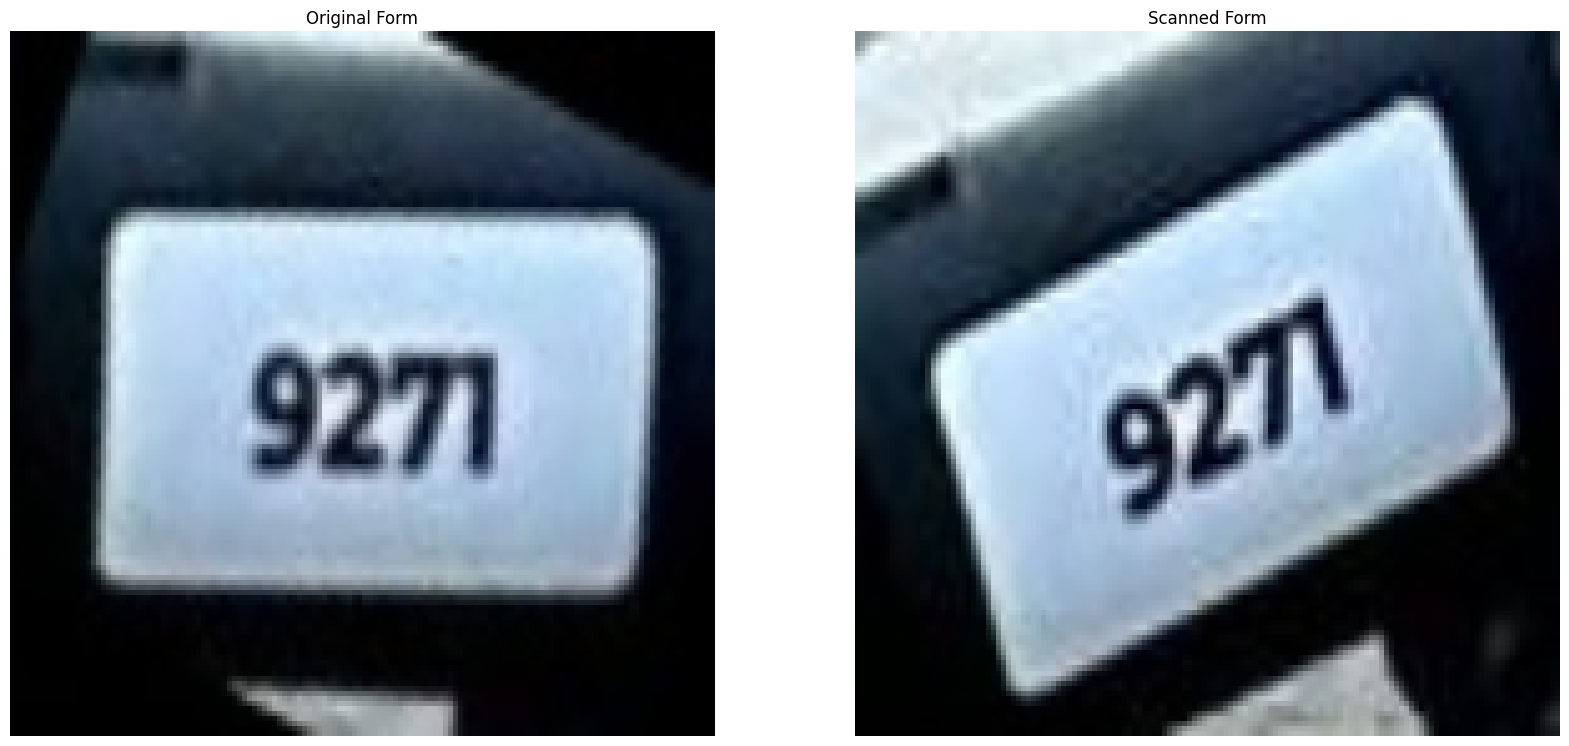

In [14]:
plt.figure(figsize = [20, 10])

plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("Original Form")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("Scanned Form")
plt.axis("off")

plt.show()

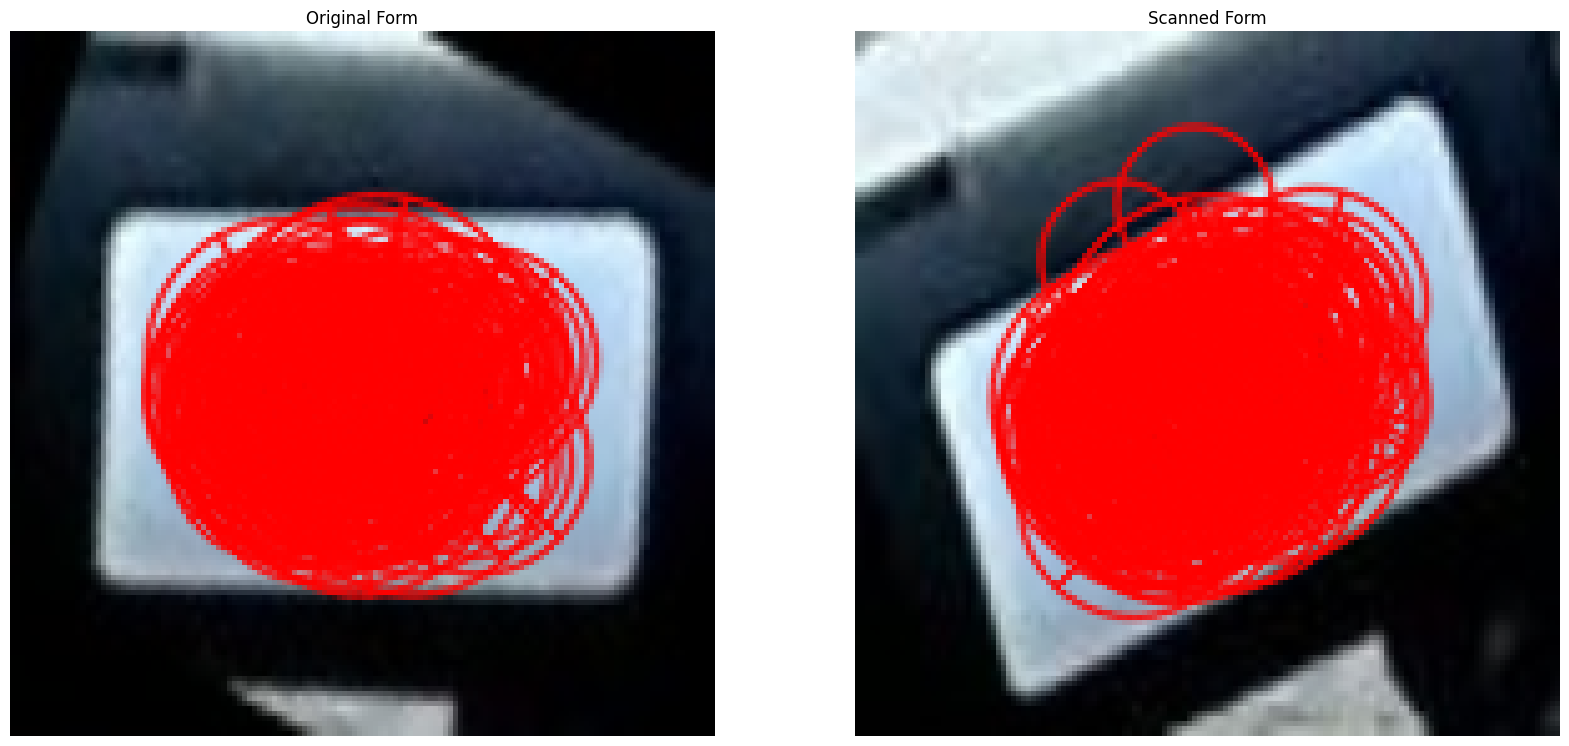

In [15]:
img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Detect ORB features and compute descriptors
MAX_NUM_FEATURES = 500
orb = cv2.ORB_create(MAX_NUM_FEATURES)
keypoints1, descriptors1 = orb.detectAndCompute(img1_gray, None)
keypoints2, descriptors2 = orb.detectAndCompute(img2_gray, None)

img1_display = cv2.drawKeypoints(img1, keypoints1,
                                 outImage = np.array([]),
                                 color = (255, 0, 0),
                                 flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

img2_display = cv2.drawKeypoints(img2, keypoints2,
                                 outImage = np.array([]),
                                 color = (255, 0, 0),
                                 flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Display Images
plt.figure(figsize = [20, 10])

plt.subplot(1, 2, 1)
plt.axis("off")
plt.imshow(img1_display)
plt.title("Original Form")

plt.subplot(1, 2, 2)
plt.axis("off")
plt.imshow(img2_display)
plt.title("Scanned Form")

plt.show()

In [17]:
# Match features.
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)

# Converting to list for sorting as tuples are immutable objects.
matches = list(matcher.match(descriptors1, descriptors2, None))

# Sort matches by score
matches.sort(key = lambda x: x.distance, reverse = False)

# Remove not so good matches
numGoodMatches = int(len(matches) * 0.1)
matches = matches[:numGoodMatches]

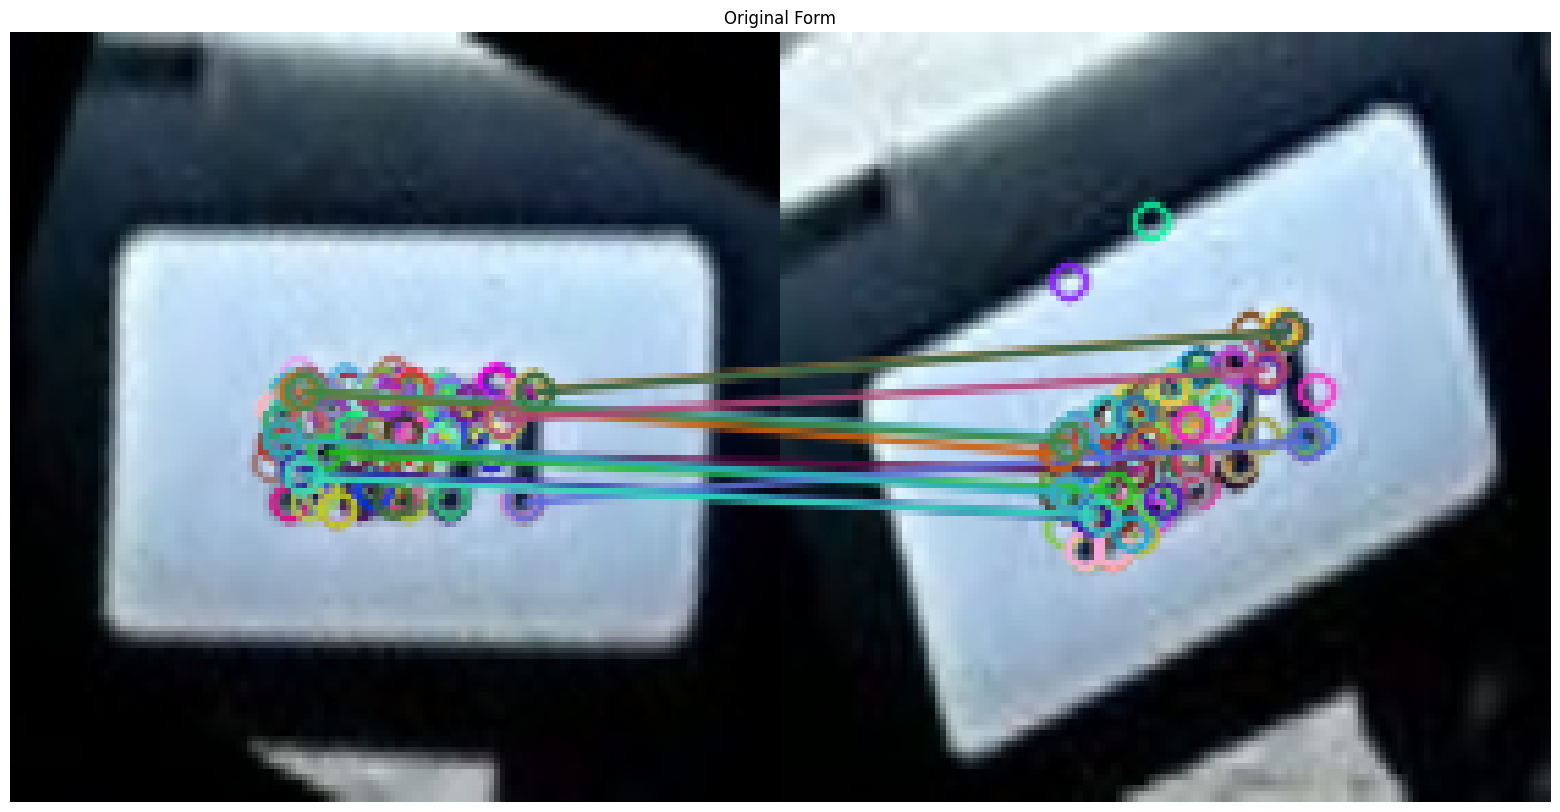

In [18]:
# Draw top matches
im_matches = cv2.drawMatches(img1, keypoints1, img2, keypoints2, matches, None)

plt.figure(figsize = [40, 10])

plt.imshow(im_matches)
plt.axis("off")
plt.title("Original Form")
plt.show()

In [19]:
# Extract location of good matches
points1 = np.zeros((len(matches), 2), dtype = np.float32)
points2 = np.zeros((len(matches), 2), dtype = np.float32)

for i, match in enumerate(matches):
    points1[i, :] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

# Find homography
h, mask = cv2.findHomography(points2, points1, cv2.RANSAC)

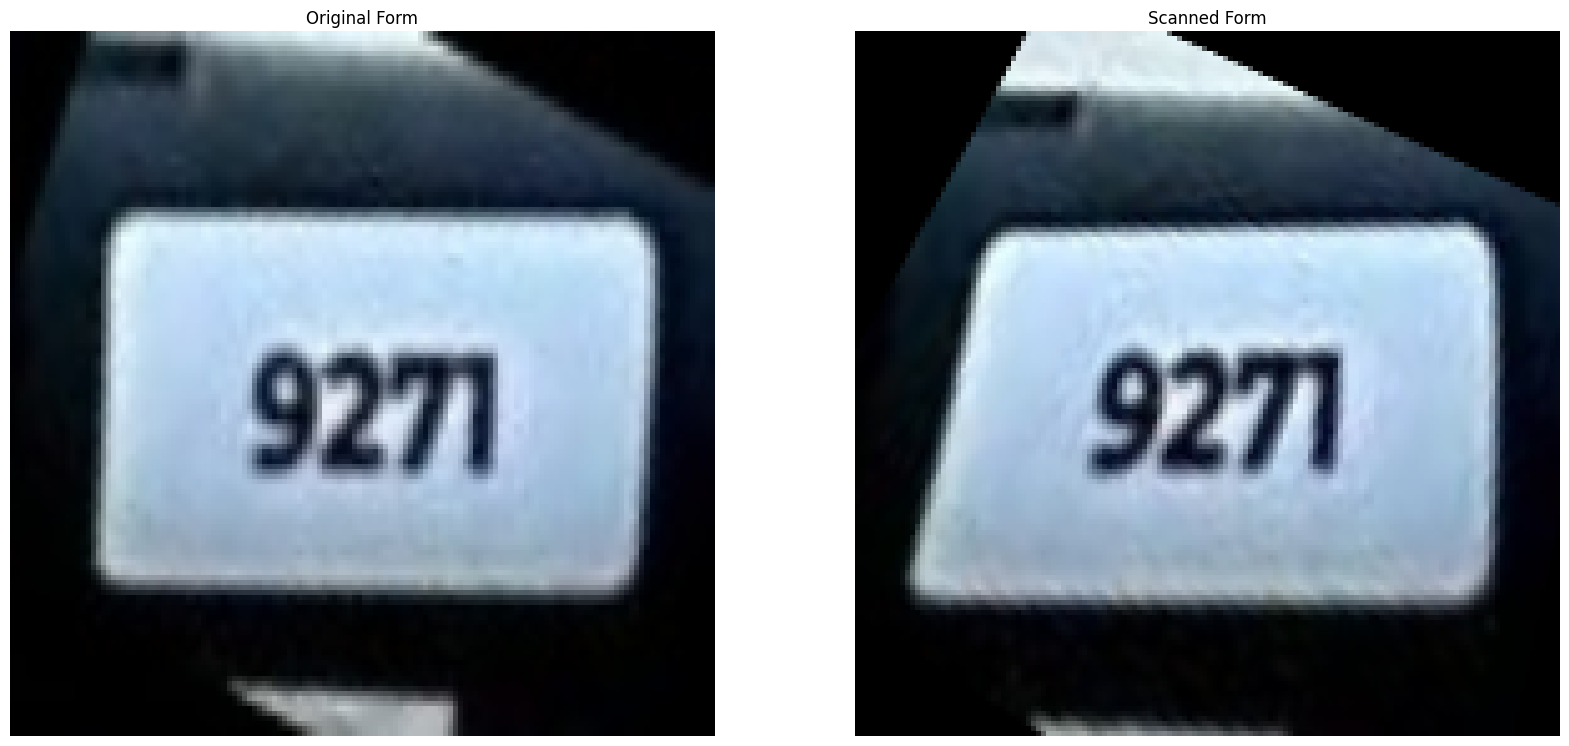

In [20]:
# Use homography to warp image
height, width, channels = img1.shape
img2_reg = cv2.warpPerspective(img2, h, (width, height))

# Display results
plt.figure(figsize = [20, 10])

plt.subplot(1, 2, 1)
plt.imshow(img1)    
plt.axis("off")
plt.title("Original Form")

plt.subplot(1, 2, 2)
plt.imshow(img2_reg)
plt.axis("off")
plt.title("Scanned Form")

plt.show()